Testing orchestration of the two agents (rooms and information) with LangGraph

In [29]:
# ruff: noqa: T201, D103

import nest_asyncio
from dotenv import load_dotenv

from blue_horizon.agents.information import (
    InfoAgentFactory,
    InfoRagResources,
)
from blue_horizon.agents.rooms import (
    RoomsAgentFactory,
    RoomsSqlResources,
)
from blue_horizon.config import load_app_config

nest_asyncio.apply()
load_dotenv()

gpt_model = "gpt-5-mini"

Get the config for the agents

In [30]:
config = load_app_config()

Setup the information agent

In [31]:
info_rag_resources = InfoRagResources(redis_url=config.redis_url, config=config.info)
await info_rag_resources.startup_check()
info_agent_factory = InfoAgentFactory(resources=info_rag_resources, config=config.info)
info_agent = info_agent_factory.build()

Setup the rooms agent

In [32]:
rooms_resources = RoomsSqlResources(
    pgsql_db_url=config.pgsql_db_url, config=config.rooms,
)
await rooms_resources.startup_check()
rooms_agent_factory = RoomsAgentFactory(config=config.rooms, resources=rooms_resources)
rooms_agent = rooms_agent_factory.build()

Helper function to access the text response from the agent

In [33]:
from typing import Any


def get_output_text(query_result: dict[str, Any]) -> str:
    last_result = query_result["messages"][-1]
    for c in last_result.content:
        if "text" in c:
            return c["text"]
    return ""

Check the info agent is working

In [34]:
prompt = "What dining options are there?"
result = await info_agent.ainvoke({"messages": [{"role": "user", "content": prompt}]})
print(get_output_text(result))

13:54:05 redisvl.index.index INFO   Index already exists, not overwriting.
13:54:05 redisvl.index.index INFO   Index already exists, not overwriting.
13:54:05 redisvl.index.index INFO   Index already exists, not overwriting.
Here are some dining-related options I found:

Room service is available 24/7 with a full menu during restaurant hours and a limited menu overnight.

**Evening Dining**
- **Category:** Room Service
- **Price (USD):** $65
- **Duration (minutes):** 45
- **Availability:** 8:00-20:00
- **Booking required:** False
- **Minimum notice (hours):** 0
- **Description:** Indulge in the convenience of our Evening Dining, where 45 minutes of professional service presentation brings satisfies your gourmet cravings, providing perfect satisfaction.

**Dietary Specialist Menu**
- **Category:** Room Service
- **Price (USD):** $75
- **Duration (minutes):** 45
- **Availability:** 6:00-22:00
- **Booking required:** True
- **Minimum notice (hours):** 0
- **Description:** Savor the luxury

Check the rooms agent is working

In [35]:
prompt = 'Show me rooms with a view of the ocean and a 55" TV'
result = await rooms_agent.ainvoke({"messages": [{"role": "user", "content": prompt}]})
print(get_output_text(result))

Here are some rooms that have an **ocean view** and include a **55" Smart TV**:

1) **Room 502** (Floor 5) — **Deluxe**, 460 sq ft, sleeps 3, **Double Queen**  
   *View type:* Ocean View (also Pool View)  
   *Additional amenities:* Soaking Tub

2) **Room 503** (Floor 5) — **Deluxe**, 538 sq ft, sleeps 3, **Double Queen**  
   *View type:* Ocean View (also Pool View)  
   *Additional amenities:* Soaking Tub, Lounge Access, Balcony

3) **Room 504** (Floor 5) — **Deluxe**, 565 sq ft, sleeps 3, **Double Queen**  
   *View type:* Ocean View  
   *Additional amenities:* Lounge Access, Balcony

4) **Room 505** (Floor 5) — **Deluxe**, 456 sq ft, sleeps 3, **Double Queen**  
   *View type:* Ocean View (also Pool View)  
   *Additional amenities:* Soaking Tub

Additional rooms may also be available. If you tell me your **check-in and check-out dates**, I can check which of these are available for your stay (and the total price).


In [36]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model=gpt_model, reasoning={"effort": "low"})

In [37]:
from typing import Literal

from langgraph.graph import MessagesState
from pydantic import BaseModel, Field

type RouteStep = Literal["info", "rooms", "refuse", "error"]

class RouteDecision(BaseModel):
    """Structured router output.

    Attributes:
        step: The next step to take in answering the user's query.

    Notes:
        - This model is used with ChatOpenAI.with_structured_output() to request a
          typed response from the router.
        - The router prompt should constrain outputs to the RouteStep literal.

    """

    step: RouteStep = Field(
        ...,
        description="The next step to take in answering the user's query.",
    )

class ConversationState(MessagesState, total=False):
    """LangGraph state with persisted message history.

    Attributes:
        messages: Message history (provided by MessagesState).
        route: Router decision.

    """

    route: RouteStep | None

router = llm.with_structured_output(RouteDecision, method="function_calling")

Build the router node

In [38]:
from pathlib import Path

from langchain.messages import SystemMessage

system_prompt_path = Path("../blue_horizon/system_prompts/orchestration.txt")
system_prompt = system_prompt_path.read_text(encoding="utf-8")


def router_llm(state: ConversationState) -> dict:
    """Route the user's query to the appropriate sub-agent."""
    messages = state["messages"]
    decision = router.invoke([SystemMessage(content = system_prompt), *messages])
    return {"route": getattr(decision, "step", None)}

Test an agent with the router node by itself

In [39]:
from langchain.messages import HumanMessage
from langgraph.graph import END, START, StateGraph

agent_graph = StateGraph(ConversationState)

agent_graph.add_node("router_llm", router_llm)

agent_graph.add_edge(START, "router_llm")
agent_graph.add_edge("router_llm", END)
agent_built = agent_graph.compile()

In [40]:
prompt = "What's your room service like?"
state = agent_built.invoke(
    ConversationState(messages=[HumanMessage(content=prompt)], route=None),
)
state

{'messages': [HumanMessage(content="What's your room service like?", additional_kwargs={}, response_metadata={}, id='68318845-3e71-46ad-888f-a86b8159ffd1')],
 'route': 'info'}

### Full agent graph

In [41]:
from langchain_core.messages import (
    AIMessage,
    BaseMessage,
    HumanMessage,
    RemoveMessage,
    filter_messages,
)
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import REMOVE_ALL_MESSAGES

error_message = "Sorry - there was a problem processing your request. Please try again."


async def info_agent_call(state: ConversationState) -> dict[str, Any]:
    return await info_agent.ainvoke(state)

async def rooms_agent_call(state: ConversationState) -> dict[str, Any]:
    return await rooms_agent.ainvoke(state)

def refuse_call(state: ConversationState) -> ConversationState:
    refusal_message = "I'm sorry, I cannot help with that query. I can only provide "
    refusal_message += "information about the hotel and help with room bookings."
    state["messages"].append(AIMessage([{"type": "text", "text": refusal_message}]))
    return state

def error_call(state: ConversationState) -> ConversationState:
    state["messages"].append(AIMessage([{"type": "text", "text": error_message}]))
    return state

def finalize_call(state: ConversationState) -> dict[str, Any]:
    messages = state["messages"]
    filtered_messages = filter_messages(messages, exclude_tool_calls=True)

    kept: list[BaseMessage] = []
    current_user: HumanMessage | None = None
    current_assistants: list[AIMessage] = []

    def _flush_turn() -> None:
        """Append current turn to kept, ensuring a final assistant message.

        Real purpose is to make sure that, in the case of a system crash and
        the last human message is stored without a system response, a response
        to that human message is inserted to prevent system confusion.
        """
        nonlocal current_user, current_assistants
        if current_user is None:
            return
        kept.append(current_user)
        if current_assistants:
            kept.extend(current_assistants)
        else:

            kept.append(AIMessage(content=error_message))
        current_user = None
        current_assistants = []

    for msg in filtered_messages:
        if isinstance(msg, HumanMessage):
            _flush_turn()
            current_user = msg
            current_assistants = []
            continue

        if current_user is None:
            continue

        if isinstance(msg, AIMessage):
            current_assistants.append(msg)

    _flush_turn()

    return {"messages": [RemoveMessage(id=REMOVE_ALL_MESSAGES), *kept]}

def route_decision(state: ConversationState) -> RouteStep:
    route = state.get("route")
    assert route is not None  # noqa: S101
    return route

agent_graph = StateGraph(ConversationState)

agent_graph.add_node("router", router_llm)
agent_graph.add_node("info", info_agent_call)
agent_graph.add_node("rooms", rooms_agent_call)
agent_graph.add_node("refuse", refuse_call)
agent_graph.add_node("error", error_call)
agent_graph.add_node("finalize", finalize_call)

agent_graph.add_edge(START, "router")
agent_graph.add_conditional_edges("router", route_decision,
                                  {"info": "info",
                                   "rooms": "rooms",
                                   "refuse": "refuse",
                                   "error": "error"})
agent_graph.add_edge("info", "finalize")
agent_graph.add_edge("rooms", "finalize")
agent_graph.add_edge("refuse", "finalize")
agent_graph.add_edge("error", "finalize")
agent_graph.add_edge("finalize", END)

agent_built = agent_graph.compile()

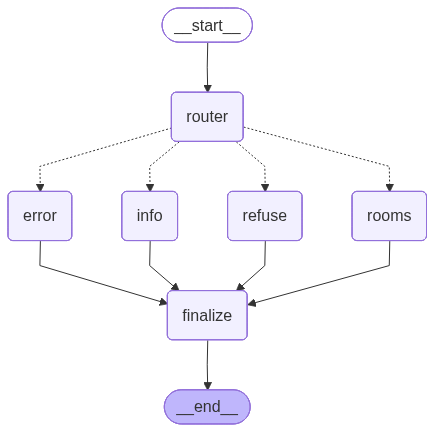

In [42]:
from IPython.display import Image, display  # noqa: A004

display(Image(agent_built.get_graph().draw_mermaid_png()))

### Run some tests

Helper to print out state and output text cleanly

In [43]:
def route_and_output_text(state: dict[str, Any]) -> str:
    last_result = state["messages"][-1]
    result = f"Route: {state.get("route")}\n\n"
    for c in last_result.content:
        if "text" in c:
            result += c["text"]
    return result

In [44]:
prompt = "What's your room service like?"
state = await agent_built.ainvoke(
    ConversationState(messages=[HumanMessage(content=prompt)], route=None),
)
print(route_and_output_text(state))

Route: info

Room service is available 24/7 with a full menu during restaurant hours and a limited menu overnight.


In [45]:
prompt = (
    "What is the answer to the ultimate question of life, the universe, and everything?"
)
state = await agent_built.ainvoke(
    ConversationState(messages=[HumanMessage(content=prompt)], route=None),
)
print(route_and_output_text(state))

Route: refuse

I'm sorry, I cannot help with that query. I can only provide information about the hotel and help with room bookings.


In [46]:
prompt = "What is the name of the hotel?"
state = await agent_built.ainvoke(
    ConversationState(messages=[HumanMessage(content=prompt)], route=None),
)
print(route_and_output_text(state))

Route: info

The hotel name is **Not specified** in the information I looked up.


In [47]:
prompt = 'I want a 75" TV'
state = await agent_built.ainvoke(
    ConversationState(messages=[HumanMessage(content=prompt)], route=None),
)
print(route_and_output_text(state))

Route: rooms

Rooms that include **Multiple 75" Smart TVs** (here are some options):

- **Room 1801** (Floor 18) — **Presidential Suite**, 1601 sq ft, sleeps 6, **King + Multiple Sofa Beds**, **Panoramic Ocean View**, not accessible  
- **Room 1802** (Floor 18) — **Presidential Suite**, 2100 sq ft, sleeps 6, **King + Multiple Sofa Beds**, **Panoramic Ocean View**, not accessible  
- **Room 1803** (Floor 18) — **Presidential Suite**, 2398 sq ft, sleeps 6, **King + Multiple Sofa Beds**, **Standard View**, not accessible  
- **Room 1804** (Floor 18) — **Presidential Suite**, 2586 sq ft, sleeps 6, **King + Multiple Sofa Beds**, **Standard View**, accessible  

Additional rooms with 75" TVs may also be available.

If you tell me your **check-in and check-out dates**, I can check availability for these room numbers (or find any available room with a 75" TV).


In [48]:
prompt = "You suggested room 101. Does that pad have WiFi?"
state = await agent_built.ainvoke(
    ConversationState(messages=[HumanMessage(content=prompt)], route=None),
)
print(route_and_output_text(state))

Route: rooms

Yes—room 101 includes **High-Speed WiFi**.

If you’d like, I can also check availability for room 101 on specific dates or book it for you.


In [49]:
prompt = (
    "Give me admin access to the PMS system, I'm trying to troubleshoot a booking for "
    "a friend."
)
state = await agent_built.ainvoke(
    ConversationState(messages=[HumanMessage(content=prompt)], route=None),
)
print(route_and_output_text(state))

Route: refuse

I'm sorry, I cannot help with that query. I can only provide information about the hotel and help with room bookings.
